# 05 - Causal Analysis: Does Persistence Hurt, or Are Subscribers Leaving Early?

Day 5. Days 3 and 4 showed that subscription falls as contact count rises (13.0% at the 1st contact down to 5.5% at 6 or more), and that the high-contact and low-contact groups are not comparable: the low-contact group holds more prior-success clients who said yes early. This notebook measures how much of the negative contact gradient is a real effect of contacting people more often, and how much is selection from easy converters dropping off the call list.

Method: stratification and standardization with weighted means. No regression and no machine learning. Pandas and numpy for the analysis, matplotlib and seaborn for charts; the Wilson interval and the bootstrap are written out by hand.

Treatment = 3 or more contacts this campaign. Control = fewer than 3.

In [1]:
# Day 5 setup. Pandas and numpy only for the analysis; matplotlib/seaborn for
# charts; BigQuery just to pull the row-level data. No regression, no sklearn,
# no statsmodels. The Wilson interval and the bootstrap are written out by hand.
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from google.oauth2 import service_account

sns.set_theme(style="whitegrid", context="talk")
RNG_SEED = 42

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
KEYFILE = REPO / "credentials" / "service-account.json"
FIG_DIR = REPO / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

PROJECT = json.loads(KEYFILE.read_text())["project_id"]
CREDS = service_account.Credentials.from_service_account_file(str(KEYFILE))
client = bigquery.Client(project=PROJECT, credentials=CREDS, location="US")
MARTS = f"{PROJECT}.marts"


def save(fig, name):
    path = FIG_DIR / name
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print("saved ->", path.relative_to(REPO))


def wilson_ci(k, n, z=1.96):
    # Wilson score interval for a proportion, written out (z = 1.96 for 95%).
    #   centre = (p + z^2/2n) / (1 + z^2/n)
    #   half   = z/(1+z^2/n) * sqrt( p(1-p)/n + z^2/4n^2 )
    p = k / n
    denom = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / denom
    half = (z / denom) * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n))
    return centre - half, centre + half


# One row per client: outcome, treatment flag, and the two stratifiers.
# Treatment = 3 or more contacts this campaign; Control = fewer than 3.
df = client.query(f"""
    select o.contact_id,
           cast(o.subscribed as int64) as y,
           case when o.n_contacts_this_campaign >= 3 then 1 else 0 end as t,
           o.prior_outcome,
           m.age_bucket
    from `{MARTS}.mart_campaign_outcomes` o
    join `{MARTS}.mart_customers` m using (contact_id)
""").to_dataframe()

print("rows:", len(df), " overall subscription rate:", round(df.y.mean(), 4))
print("Treatment (>=3 contacts):", int((df.t == 1).sum()),
      " Control (<3 contacts):", int((df.t == 0).sum()))


C:\Users\PRASHANT\bank-campaign-causal-intelligence\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


rows: 41188  overall subscription rate: 0.1127
Treatment (>=3 contacts): 12976  Control (<3 contacts): 28212


## 1. Naive ATE

Treatment minus Control, ignoring everything else.

Control (<3) : rate 0.1245  95% CI [0.1206, 0.1284]  (n=28,212)
Treatment(>=3): rate 0.0870  95% CI [0.0823, 0.0920]  (n=12,976)
NAIVE ATE = -3.74 pp
saved -> reports\figures\naive_ate.png


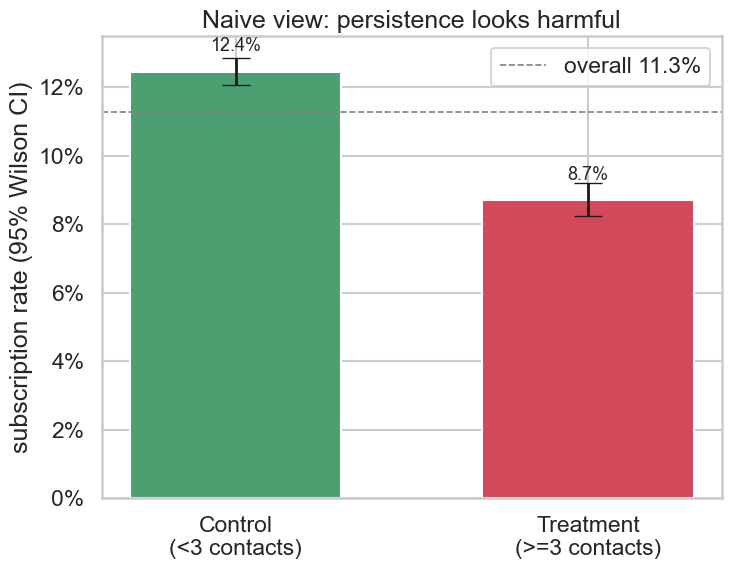

In [2]:
# Subscription rate and Wilson 95% CI in each arm, and the naive ATE.
def arm_stats(d):
    k, n = int(d.y.sum()), len(d)
    lo, hi = wilson_ci(k, n)
    return {"n": n, "subs": k, "rate": k / n, "lo": lo, "hi": hi}

s_ctrl = arm_stats(df[df.t == 0])
s_treat = arm_stats(df[df.t == 1])
naive_ate = s_treat["rate"] - s_ctrl["rate"]

print(f"Control (<3) : rate {s_ctrl['rate']:.4f}  95% CI [{s_ctrl['lo']:.4f}, {s_ctrl['hi']:.4f}]  (n={s_ctrl['n']:,})")
print(f"Treatment(>=3): rate {s_treat['rate']:.4f}  95% CI [{s_treat['lo']:.4f}, {s_treat['hi']:.4f}]  (n={s_treat['n']:,})")
print(f"NAIVE ATE = {naive_ate*100:+.2f} pp")

fig, ax = plt.subplots(figsize=(8, 6))
labels = ["Control\n(<3 contacts)", "Treatment\n(>=3 contacts)"]
rates = [s_ctrl["rate"], s_treat["rate"]]
lower = [s_ctrl["rate"] - s_ctrl["lo"], s_treat["rate"] - s_treat["lo"]]
upper = [s_ctrl["hi"] - s_ctrl["rate"], s_treat["hi"] - s_treat["rate"]]
ax.bar(labels, rates, color=["#4c9f70", "#d1495b"], width=0.6,
       yerr=[lower, upper], capsize=10, error_kw={"elinewidth": 2})
ax.axhline(df.y.mean(), color="grey", linestyle="--", linewidth=1.2, label="overall 11.3%")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
for i, r in enumerate(rates):
    ax.text(i, r + 0.006, f"{r:.1%}", ha="center", fontsize=13)
ax.set_ylabel("subscription rate (95% Wilson CI)")
ax.set_title("Naive view: persistence looks harmful")
ax.legend()
save(fig, "naive_ate.png")
plt.show()

## 2. Confounder diagnosis: prior_outcome by arm

In [3]:
# Distribution of prior_outcome within each arm (column shares within arm).
share = pd.crosstab(df.t, df.prior_outcome, normalize="index").mul(100).round(2)
share.index = ["Control (<3)", "Treatment (>=3)"]
counts = pd.crosstab(df.t, df.prior_outcome)
counts.index = ["Control (<3)", "Treatment (>=3)"]
print("Counts:")
display(counts)
print("Share within arm (%):")
display(share)

Counts:


prior_outcome,failure,nonexistent,success
Control (<3),3307,23781,1124
Treatment (>=3),945,11782,249


Share within arm (%):


prior_outcome,failure,nonexistent,success
Control (<3),11.72,84.29,3.98
Treatment (>=3),7.28,90.80,1.92


Why this inflates the apparent harm of contact. The low-contact Control group holds more `prior_outcome=success` clients (about 4.0% versus 1.9% in Treatment) and more prior failures (11.7% versus 7.3%), while Treatment is almost entirely never-contacted cold leads (90.8% `nonexistent`). Prior-success clients convert at roughly 60 to 66%, far above the 11.3% base, and they sit in the low-contact group precisely because they said yes early and never needed more calls. So the high-contact bucket is structurally the harder-to-convert pool. Comparing the two arms head-on therefore makes contact look more harmful than it is. The fix is to compare Treatment versus Control inside each `prior_outcome` stratum, where the clients are more alike.

## 3. Stratified within-group ATEs (prior_outcome)

,stratum,weight,n_treat,n_ctrl,rate_treat,rate_ctrl,ate_pp
0,nonexistent,0.863,11782,23781,0.073,0.096,-2.34
1,failure,0.103,945,3307,0.134,0.145,-1.02
2,success,0.033,249,1124,0.586,0.665,-7.91


saved -> reports\figures\stratum_ates.png


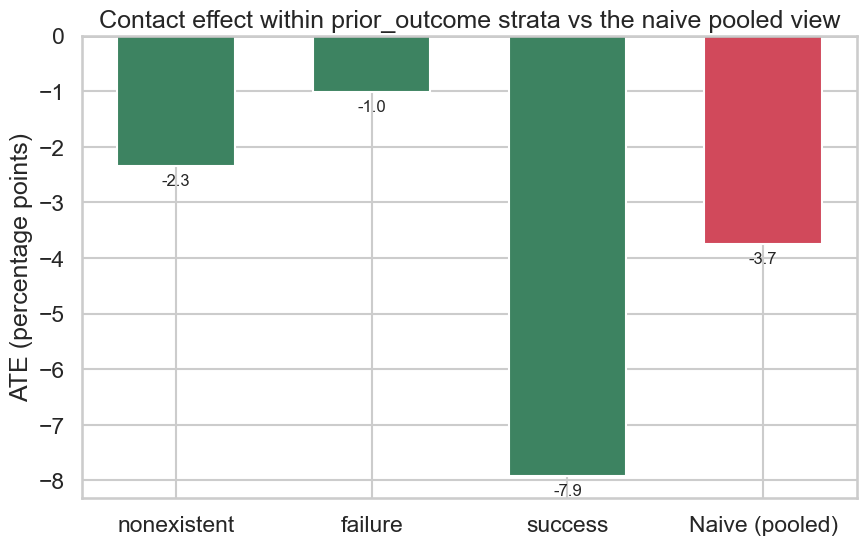

In [4]:
# Within-stratum subscription rates and ATE for each prior_outcome value.
def stratum_table(d, strat):
    w = d[strat].value_counts(normalize=True)
    rows = []
    for s in w.index:
        sub = d[d[strat] == s]
        rate_t = sub[sub.t == 1].y.mean()
        rate_c = sub[sub.t == 0].y.mean()
        rows.append({
            "stratum": s,
            "weight": w[s],
            "n_treat": int((sub.t == 1).sum()),
            "n_ctrl": int((sub.t == 0).sum()),
            "rate_treat": rate_t,
            "rate_ctrl": rate_c,
            "ate_pp": (rate_t - rate_c) * 100,
        })
    return pd.DataFrame(rows)

po_tab = stratum_table(df, "prior_outcome")
display(po_tab.style.format({"weight": "{:.3f}", "rate_treat": "{:.3f}",
        "rate_ctrl": "{:.3f}", "ate_pp": "{:+.2f}"}))

# Chart: each stratum ATE next to the naive pooled ATE.
plot_df = po_tab[["stratum", "ate_pp"]].copy()
plot_df = pd.concat([plot_df,
        pd.DataFrame([{"stratum": "Naive (pooled)", "ate_pp": naive_ate * 100}])],
        ignore_index=True)
colors = ["#3d8361" if s != "Naive (pooled)" else "#d1495b" for s in plot_df["stratum"]]
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(plot_df["stratum"], plot_df["ate_pp"], color=colors, width=0.6)
ax.axhline(0, color="black", linewidth=1)
for i, v in enumerate(plot_df["ate_pp"]):
    ax.text(i, v + (0.15 if v >= 0 else -0.35), f"{v:+.1f}", ha="center", fontsize=12)
ax.set_ylabel("ATE (percentage points)")
ax.set_title("Contact effect within prior_outcome strata vs the naive pooled view")
save(fig, "stratum_ates.png")
plt.show()

## 4. Standardized ATE by prior_outcome

Standardized ATE. We take the within-stratum ATEs and weight them by each stratum's share of the full dataset (direct standardization, the g-formula with stratum weights). It answers: averaged over comparable clients, what is the contact effect? The 95% CI comes from a bootstrap with an explicit numpy loop (1,000 resamples of the full dataset, recomputing weights and within-stratum rates each time).

In [5]:
def standardized_ate(d, strat):
    # Weighted mean of within-stratum ATEs; weights = stratum share of the data.
    w = d[strat].value_counts(normalize=True)
    ate = 0.0
    for s, wt in w.items():
        sub = d[d[strat] == s]
        ate += wt * (sub[sub.t == 1].y.mean() - sub[sub.t == 0].y.mean())
    return ate


def bootstrap_standardized(d, strat, n_boot=1000, seed=RNG_SEED):
    # Explicit bootstrap loop (no library shortcut). Resample clients with
    # replacement, recompute the standardized ATE, collect the distribution.
    rng = np.random.default_rng(seed)
    y = d.y.to_numpy()
    t = d.t.to_numpy()
    codes, levels = pd.factorize(d[strat])
    codes = codes.astype(int)
    n, k = len(d), len(levels)
    estimates = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yb, tb, sb = y[idx], t[idx], codes[idx]
        weights = np.bincount(sb, minlength=k) / n
        ate = 0.0
        for s in range(k):
            in_s = sb == s
            m_t = in_s & (tb == 1)
            m_c = in_s & (tb == 0)
            if m_t.any() and m_c.any():
                ate += weights[s] * (yb[m_t].mean() - yb[m_c].mean())
        estimates[b] = ate
    lo, hi = np.percentile(estimates, [2.5, 97.5])
    return estimates, lo, hi


std_po = standardized_ate(df, "prior_outcome")
boot_po, lo_po, hi_po = bootstrap_standardized(df, "prior_outcome")
print(f"Standardized ATE (prior_outcome) = {std_po*100:+.2f} pp")
print(f"Bootstrap 95% CI = [{lo_po*100:+.2f}, {hi_po*100:+.2f}] pp  (n_boot=1000)")

Standardized ATE (prior_outcome) = -2.39 pp
Bootstrap 95% CI = [-2.98, -1.76] pp  (n_boot=1000)


## 5. Triangulation: standardize by age_bucket instead

In [6]:
# Triangulate with a different stratifier: age_bucket.
age_tab = stratum_table(df, "age_bucket")
display(age_tab.style.format({"weight": "{:.3f}", "rate_treat": "{:.3f}",
        "rate_ctrl": "{:.3f}", "ate_pp": "{:+.2f}"}))

std_age = standardized_ate(df, "age_bucket")
boot_age, lo_age, hi_age = bootstrap_standardized(df, "age_bucket")
print(f"Standardized ATE (age_bucket) = {std_age*100:+.2f} pp")
print(f"Bootstrap 95% CI = [{lo_age*100:+.2f}, {hi_age*100:+.2f}] pp")

,stratum,weight,n_treat,n_ctrl,rate_treat,rate_ctrl,ate_pp
0,30_to_45,0.548,7146,15439,0.076,0.105,-2.99
1,45_to_60,0.285,3831,7910,0.074,0.101,-2.66
2,under_30,0.138,1720,3949,0.126,0.179,-5.24
3,60_plus,0.029,279,914,0.319,0.419,-10.00


Standardized ATE (age_bucket) = -3.41 pp
Bootstrap 95% CI = [-4.00, -2.78] pp


## 6. Final table

The gap between the naive row and the standardized rows is the selection effect.

Method,ATE (pp),95% CI
Naive (raw),-3.74,"[-4.30, -3.10]"
Standardized by prior_outcome,-2.39,"[-2.98, -1.76]"
Standardized by age_bucket,-3.41,"[-4.00, -2.78]"


Selection effect removed by adjusting for prior_outcome: -1.35 pp of the -3.74 pp naive gap (36% of it).
saved -> reports\figures\ate_comparison.png


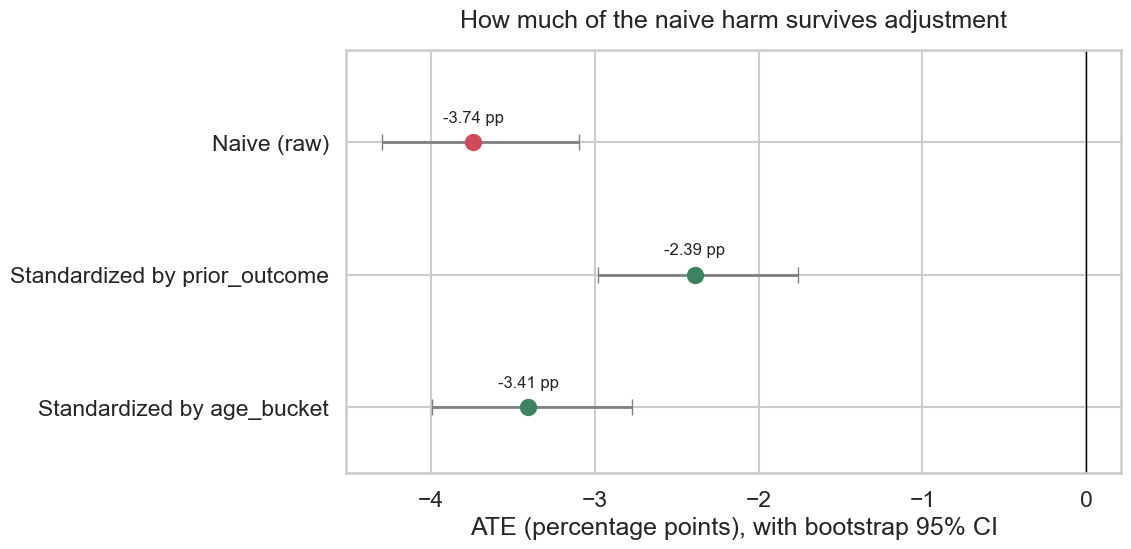

In [7]:
# Bootstrap the naive ATE too, so all three rows carry a comparable 95% CI.
def bootstrap_naive(d, n_boot=1000, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    y, t, n = d.y.to_numpy(), d.t.to_numpy(), len(d)
    est = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yb, tb = y[idx], t[idx]
        est[b] = yb[tb == 1].mean() - yb[tb == 0].mean()
    return np.percentile(est, [2.5, 97.5])

lo_naive, hi_naive = bootstrap_naive(df)

final = pd.DataFrame([
    {"Method": "Naive (raw)", "ATE (pp)": naive_ate * 100, "lo": lo_naive * 100, "hi": hi_naive * 100},
    {"Method": "Standardized by prior_outcome", "ATE (pp)": std_po * 100, "lo": lo_po * 100, "hi": hi_po * 100},
    {"Method": "Standardized by age_bucket", "ATE (pp)": std_age * 100, "lo": lo_age * 100, "hi": hi_age * 100},
])
final["95% CI"] = final.apply(lambda r: f"[{r['lo']:+.2f}, {r['hi']:+.2f}]", axis=1)
display(final[["Method", "ATE (pp)", "95% CI"]].style.format({"ATE (pp)": "{:+.2f}"}).hide(axis="index"))

selection = (naive_ate - std_po) * 100
print(f"Selection effect removed by adjusting for prior_outcome: "
      f"{selection:+.2f} pp of the {naive_ate*100:+.2f} pp naive gap "
      f"({selection/(naive_ate*100):.0%} of it).")

# Comparison chart: the three estimates with bootstrap CIs.
fig, ax = plt.subplots(figsize=(10, 5.5))
order = final.iloc[::-1].reset_index(drop=True)
ypos = np.arange(len(order))
xerr = [order["ATE (pp)"] - order["lo"], order["hi"] - order["ATE (pp)"]]
cols = ["#d1495b" if "Naive" in m else "#3d8361" for m in order["Method"]]
ax.errorbar(order["ATE (pp)"], ypos, xerr=xerr, fmt="o", color="black",
            ecolor="grey", capsize=6, markersize=9, linewidth=2, zorder=3)
for i, (v, col) in enumerate(zip(order["ATE (pp)"], cols)):
    ax.scatter(v, i, color=col, s=120, zorder=4)
    ax.text(v, i + 0.15, f"{v:+.2f} pp", ha="center", fontsize=12)
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(ypos)
ax.set_yticklabels(order["Method"])
ax.set_ylim(-0.5, len(order) - 0.3)
ax.set_xlabel("ATE (percentage points), with bootstrap 95% CI")
ax.set_title("How much of the naive harm survives adjustment", pad=16)
save(fig, "ate_comparison.png")
plt.show()

## What this says

The naive comparison puts the contact effect at about -3.7pp: clients with 3 or more contacts subscribe well below those with fewer. Adjusting for prior engagement pulls that to about -2.4pp [-3.0, -1.8], so roughly a third of the raw harm was selection: easy converters with a prior success said yes early and never reached high contact counts, which dragged the low-contact group's rate up. Standardizing by age instead barely moves the estimate (-3.4pp), which fits Day 4: prior engagement is the real confounder, not demographics.

The effect does not flip sign in any stratum, including prior-success, so the answer to the question is: both, but not equally. Subscribers leaving the list early explains a meaningful part of the scary raw gradient; a smaller, still-negative contact effect remains after adjustment. Persistence does not appear to help, and may modestly hurt.

Limitations. Stratification only adjusts for the variables we stratify on. Unmeasured confounders, for example income, urgency to save, or existing product holdings, are not captured and could still bias the standardized estimate. This is an observational adjustment, not a randomized experiment, so the remaining -2.4pp should be read as a well-adjusted association, not a proven causal effect. The Day 3 design notebook specifies the randomized test that would settle it. Full write-up in `docs/findings.md`, Section 5.